In [1]:
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

In [2]:
%load_ext autoreload 
%autoreload 2

## Load ins

In [3]:
df = pd.read_csv("Data/ignore/panel_data.csv")
df = df.drop("DATE", axis = 1)

df['date'] = pd.to_datetime(df["date"])

df["date"] = df["date"].dt.floor("D")

df.columns = df.columns.str.lower()

df.head()

,metro,date,regular,mid,premium,diesel,reg_delt,met,lat,lng,...,usa_rmw,usa_eye,usa_gust,usa_seahgt,storm_speed,storm_dir,distance,mid_delt,premium_delt,diesel_delt
0,Bradenton-Sarasota-Venice,2022-01-21,3.236000,3.625,3.915000,3.563000,NaN,North Port-Bradenton-Sarasota,27.3479,-82.3223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bradenton-Sarasota-Venice,2022-01-22,3.254667,3.639,3.929667,3.587667,0.576844,North Port-Bradenton-Sarasota,27.3479,-82.3223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386207,0.374628,0.692300
2,Bradenton-Sarasota-Venice,2022-01-23,3.273333,3.653,3.944333,3.612333,0.573535,North Port-Bradenton-Sarasota,27.3479,-82.3223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.384721,0.373229,0.687541
3,Bradenton-Sarasota-Venice,2022-01-24,3.292000,3.667,3.959000,3.637000,0.570265,North Port-Bradenton-Sarasota,27.3479,-82.3223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.383247,0.371841,0.682846
4,Bradenton-Sarasota-Venice,2022-01-25,3.310667,3.681,3.973667,3.661667,0.567031,North Port-Bradenton-Sarasota,27.3479,-82.3223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.381783,0.370464,0.678215


## Covariate correlation check

<Axes: >

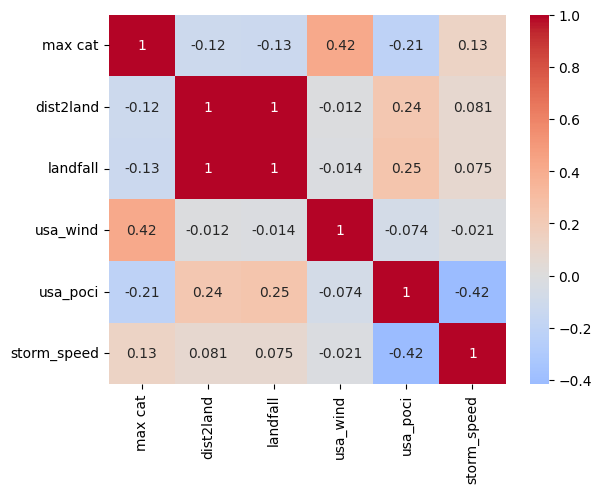

In [4]:
regressors = ["max cat", "dist2land", "landfall", "usa_wind", "usa_poci", "storm_speed"]
corr = df[regressors].corr()

sns.heatmap(corr, annot= True, cmap = "coolwarm", center=0)

**Key takeaways**

Cannot include both `dist2land` and `landfall` -> kept `dist2land`

`max_cat` and `usa_wind` are highly correlated 

Kept both `dist2land` and `usa_wind` because these are continuous. 

Pressure and storm speed are related but I kept both

## Storm

In [5]:
from src.storm_regression import storm_ols

In [6]:
df["name"].unique()

<StringArray>
[        nan,    'BONNIE',  'DANIELLE',     'FIONA',       'IAN',     'JULIA',
      'LISA',    'NICOLE',       'DON',  'FRANKLIN',       'LEE',     'NIGEL',
     'TAMMY',     'BERYL',     'DEBBY',   'ERNESTO',  'FRANCINE',    'HELENE',
     'ISAAC',      'KIRK',    'LESLIE',     'OSCAR',    'RAFAEL',      'ERIN',
 'GABRIELLE',  'HUMBERTO',    'IMELDA',   'MELISSA']
Length: 28, dtype: str

                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.5322
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.661
Time:                        14:28:35   Log-Likelihood:                 88.680
No. Observations:                  96   AIC:                            -169.4
Df Residuals:                      92   BIC:                            -159.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0568      0.074     -0.767      

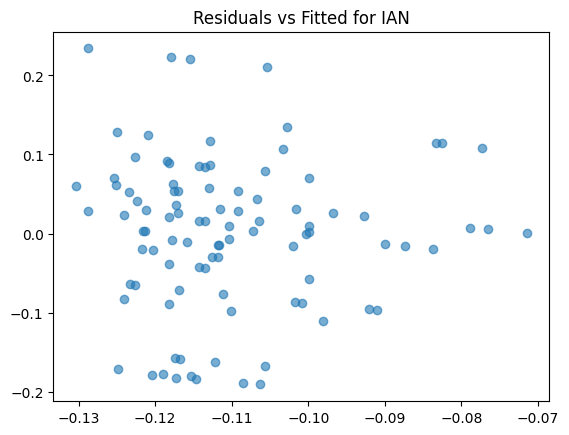

In [7]:
model_bonnie, df_bonnie = storm_ols(
    df = df,
    storm_name = 'IAN',
    outcome = "reg_delt",
    regressors = ["storm_speed", "distance", "dist2land"],
    diagnostic=True
)

In [8]:
df.columns

Index(['metro', 'date', 'regular', 'mid', 'premium', 'diesel', 'reg_delt',
       'met', 'lat', 'lng', 'month', 'sid', 'season', 'name', 'max cat',
       'start date', 'end date', 'storm duration', 'iso_time', 'nature',
       'dist2land', 'landfall', 'usa_lat', 'usa_lon', 'usa_record',
       'usa_status', 'usa_wind', 'usa_pres', 'usa_sshs', 'usa_poci',
       'usa_roci', 'usa_rmw', 'usa_eye', 'usa_gust', 'usa_seahgt',
       'storm_speed', 'storm_dir', 'distance', 'mid_delt', 'premium_delt',
       'diesel_delt'],
      dtype='str')

                            OLS Regression Results                            
Dep. Variable:            diesel_delt   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     14.30
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           8.08e-09
Time:                        14:28:35   Log-Likelihood:                 185.85
No. Observations:                 360   AIC:                            -363.7
Df Residuals:                     356   BIC:                            -348.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4526      0.043    -10.469      

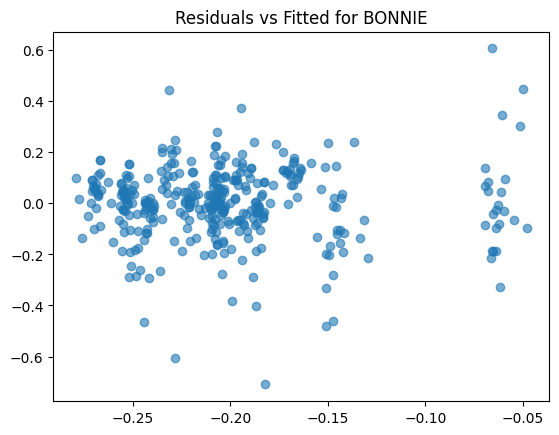

In [9]:
model_bonnie, df_bonnie = storm_ols(
    df = df,
    storm_name = 'BONNIE',
    outcome = "diesel_delt",
    regressors = ["storm_speed", "distance", "dist2land"],
    diagnostic=True
)

## Split

In [10]:
from src.storm_regression import ols_train_test

## Performance

In [11]:
r = ["dist2land", "usa_wind", "storm_speed"]
m =  'Miami-Fort Lauderdale-West Palm Beach'

model, performance = ols_train_test(df, m, "reg_delt", r, test_size = .2)

Rows in model_df: 762
X shape: (762, 3)
y shape: (762,)
                                0
observations           762.000000
observations in train  609.000000
observations in test   153.000000
train_rmse               0.652141
test_rmse                0.463996
train_r2                 0.012194
test_r2                 -0.094145


In [12]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.490
Date:                Mon, 13 Apr 2026   Prob (F-statistic):             0.0594
Time:                        14:28:35   Log-Likelihood:                -603.79
No. Observations:                 609   AIC:                             1216.
Df Residuals:                     605   BIC:                             1233.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1595      0.083      1.925      

## Model selection -> forward selection 

In [13]:
regressors = ["max cat", "dist2land", "landfall", "usa_wind", "usa_poci", "storm_speed"]


                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     8.707
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           0.000214
Time:                        19:15:29   Log-Likelihood:                -428.07
No. Observations:                 288   AIC:                             862.1
Df Residuals:                     285   BIC:                             873.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.197      0.003      0.9

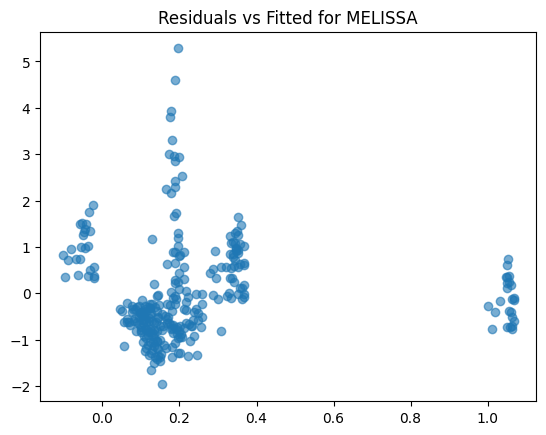

                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     7.968
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           4.06e-05
Time:                        19:15:29   Log-Likelihood:                -424.97
No. Observations:                 288   AIC:                             857.9
Df Residuals:                     284   BIC:                             872.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.2961      0.229      1.293      

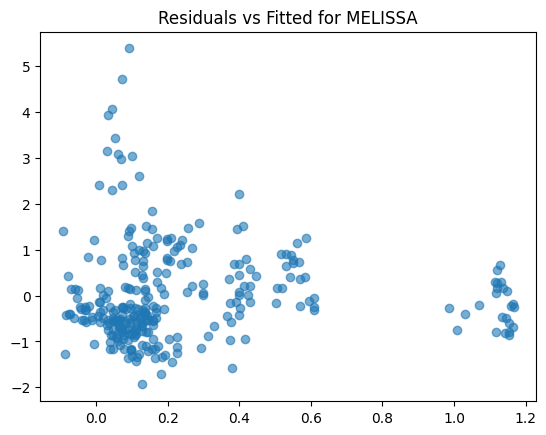

                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     12.43
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           2.52e-09
Time:                        19:15:29   Log-Likelihood:                -413.31
No. Observations:                 288   AIC:                             836.6
Df Residuals:                     283   BIC:                             854.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.6110      0.348      4.633      

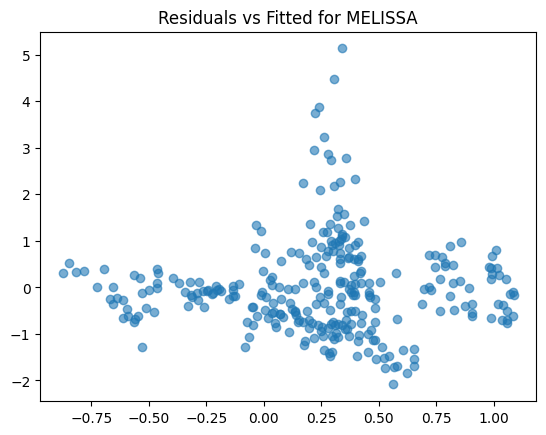

In [41]:
model_bonnie3, df_bonnie3 = storm_ols(
    df = df,
    storm_name = 'MELISSA',
    outcome = "reg_delt",
    regressors = ["distance", "dist2land"],
    diagnostic=True
)

model_bonnie, df_bonnie = storm_ols(
    df = df,
    storm_name = 'MELISSA',
    outcome = "reg_delt",
    regressors = ["storm_speed", "distance", "dist2land"],
    diagnostic=True
)

model_bonnie2, df_bonnie2 = storm_ols(
    df = df,
    storm_name = 'MELISSA',
    outcome = "reg_delt",
    regressors = ["storm_speed", "distance", "dist2land", "usa_wind"],
    diagnostic=True
)

## outputs with stargazer

In [15]:
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

In [16]:
stargazer = Stargazer([model_bonnie3, model_bonnie, model_bonnie2])
stargazer.title("Regression results for Hurricane Bonnie on pct. change in Regular Gas Price")
HTML(stargazer.render_html())

In [17]:
df.columns

Index(['metro', 'date', 'regular', 'mid', 'premium', 'diesel', 'reg_delt',
       'met', 'lat', 'lng', 'month', 'sid', 'season', 'name', 'max cat',
       'start date', 'end date', 'storm duration', 'iso_time', 'nature',
       'dist2land', 'landfall', 'usa_lat', 'usa_lon', 'usa_record',
       'usa_status', 'usa_wind', 'usa_pres', 'usa_sshs', 'usa_poci',
       'usa_roci', 'usa_rmw', 'usa_eye', 'usa_gust', 'usa_seahgt',
       'storm_speed', 'storm_dir', 'distance', 'mid_delt', 'premium_delt',
       'diesel_delt'],
      dtype='str')

                            OLS Regression Results                            
Dep. Variable:           premium_delt   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     2.721
Date:                Mon, 13 Apr 2026   Prob (F-statistic):             0.0711
Time:                        14:28:36   Log-Likelihood:                 9.5675
No. Observations:                  96   AIC:                            -13.14
Df Residuals:                      93   BIC:                            -5.442
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0650      0.056     -1.169      0.2

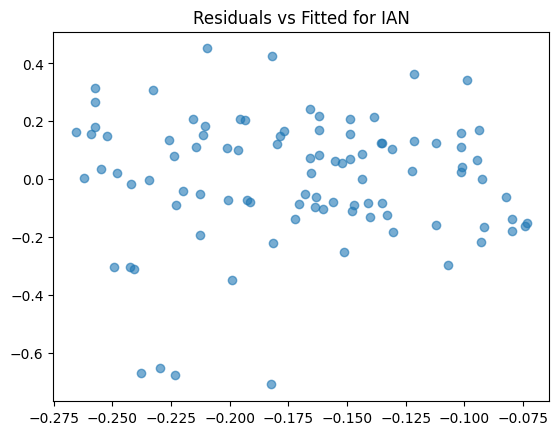

                            OLS Regression Results                            
Dep. Variable:           premium_delt   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     4.882
Date:                Mon, 13 Apr 2026   Prob (F-statistic):            0.00340
Time:                        14:28:36   Log-Likelihood:                 13.929
No. Observations:                  96   AIC:                            -19.86
Df Residuals:                      92   BIC:                            -9.600
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.5149      0.161     -3.194      

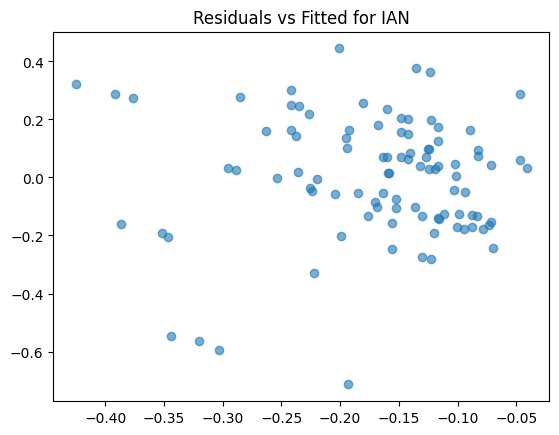

                            OLS Regression Results                            
Dep. Variable:           premium_delt   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     3.794
Date:                Mon, 13 Apr 2026   Prob (F-statistic):            0.00672
Time:                        14:28:36   Log-Likelihood:                 14.242
No. Observations:                  96   AIC:                            -18.48
Df Residuals:                      91   BIC:                            -5.662
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.7807      0.380     -2.052      

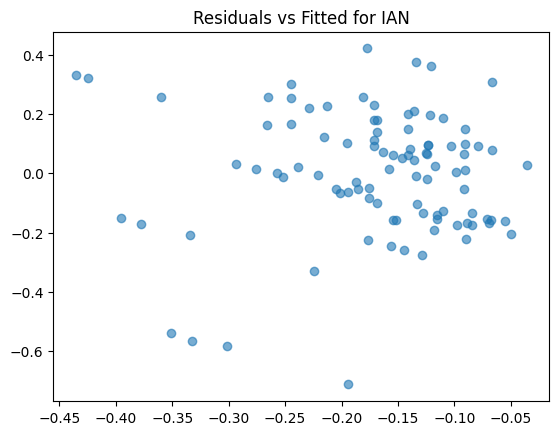

In [18]:
model_bonnie3, df_bonnie3 = storm_ols(
    df = df,
    storm_name = 'IAN',
    outcome = "premium_delt",
    regressors = ["distance", "dist2land"],
    diagnostic=True
)

model_bonnie, df_bonnie = storm_ols(
    df = df,
    storm_name = 'IAN',
    outcome = "premium_delt",
    regressors = ["storm_speed", "distance", "dist2land"],
    diagnostic=True
)

model_bonnie2, df_bonnie2 = storm_ols(
    df = df,
    storm_name = 'IAN',
    outcome = "premium_delt",
    regressors = ["storm_speed", "distance", "dist2land", "usa_wind"],
    diagnostic=True
)

stargazer = Stargazer([model_bonnie3, model_bonnie, model_bonnie2])
stargazer.title("Regression results for Hurricane Ian on pct. change in Premium Gas Price")
HTML(stargazer.render_html())

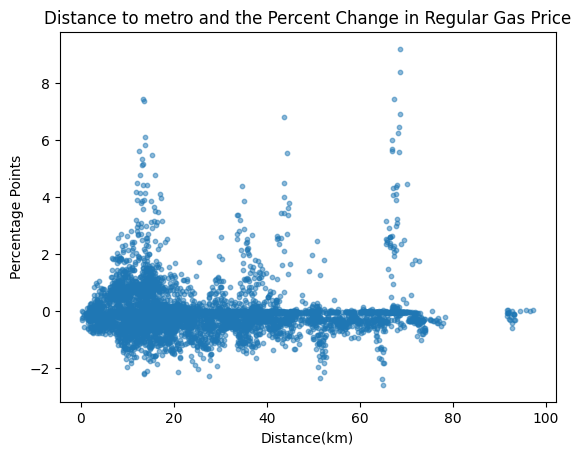

In [19]:
plt.scatter(df["distance"], df["reg_delt"], s = 10, alpha = .5)
plt.xlabel('Distance(km)')
plt.ylabel('Percentage Points')
plt.title('Distance to metro and the Percent Change in Regular Gas Price')
plt.show()

In [20]:
r = ["dist2land", "usa_wind", "storm_speed"]
m =  'Miami-Fort Lauderdale-West Palm Beach'
print("\n Miami/Ft. Laudertale/West Palm Beach \n")
model, performance = ols_train_test(df, m, "premium_delt", r, test_size = .2)


 Miami/Ft. Laudertale/West Palm Beach 

Rows in model_df: 762
X shape: (762, 3)
y shape: (762,)
                                0
observations           762.000000
observations in train  609.000000
observations in test   153.000000
train_rmse               0.498529
test_rmse                0.441547
train_r2                 0.006118
test_r2                 -0.027580


In [21]:
df["name"].unique()

<StringArray>
[        nan,    'BONNIE',  'DANIELLE',     'FIONA',       'IAN',     'JULIA',
      'LISA',    'NICOLE',       'DON',  'FRANKLIN',       'LEE',     'NIGEL',
     'TAMMY',     'BERYL',     'DEBBY',   'ERNESTO',  'FRANCINE',    'HELENE',
     'ISAAC',      'KIRK',    'LESLIE',     'OSCAR',    'RAFAEL',      'ERIN',
 'GABRIELLE',  'HUMBERTO',    'IMELDA',   'MELISSA']
Length: 28, dtype: str

In [22]:
df.columns

Index(['metro', 'date', 'regular', 'mid', 'premium', 'diesel', 'reg_delt',
       'met', 'lat', 'lng', 'month', 'sid', 'season', 'name', 'max cat',
       'start date', 'end date', 'storm duration', 'iso_time', 'nature',
       'dist2land', 'landfall', 'usa_lat', 'usa_lon', 'usa_record',
       'usa_status', 'usa_wind', 'usa_pres', 'usa_sshs', 'usa_poci',
       'usa_roci', 'usa_rmw', 'usa_eye', 'usa_gust', 'usa_seahgt',
       'storm_speed', 'storm_dir', 'distance', 'mid_delt', 'premium_delt',
       'diesel_delt'],
      dtype='str')

## Scaling using scikit-learn

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ["distance", "usa_wind", "storm_speed"]

scaled_values = scaler.fit_transform(df[cols])

df[[c + "_z" for c in cols]] = scaled_values # didnt want to overwrigt

                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     8.707
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           0.000214
Time:                        14:28:36   Log-Likelihood:                -428.07
No. Observations:                 288   AIC:                             862.1
Df Residuals:                     285   BIC:                             873.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3021      0.197     -1.535      0.1

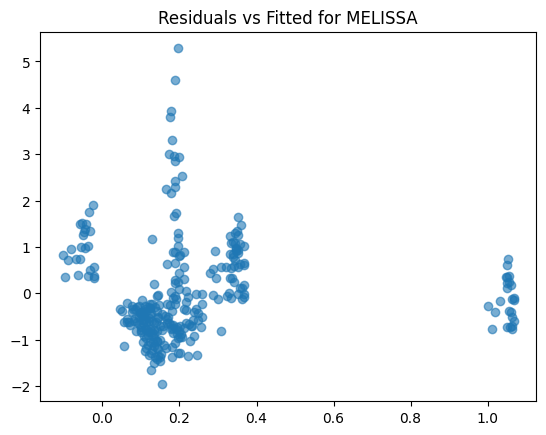

                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     10.38
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.67e-06
Time:                        14:28:36   Log-Likelihood:                -421.63
No. Observations:                 288   AIC:                             851.3
Df Residuals:                     284   BIC:                             865.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2687      0.193     -1.392      0.1

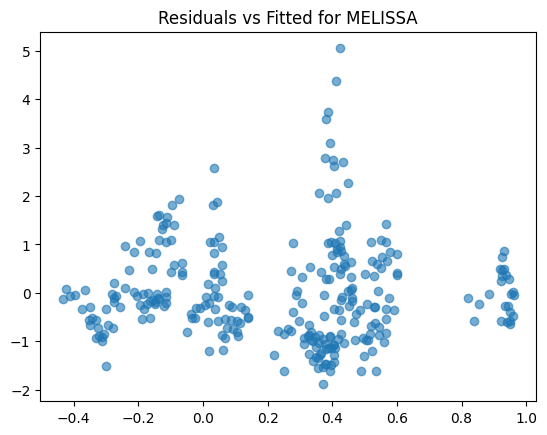

                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     12.43
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           2.52e-09
Time:                        14:28:36   Log-Likelihood:                -413.31
No. Observations:                 288   AIC:                             836.6
Df Residuals:                     283   BIC:                             854.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.6462      0.209     -3.089      

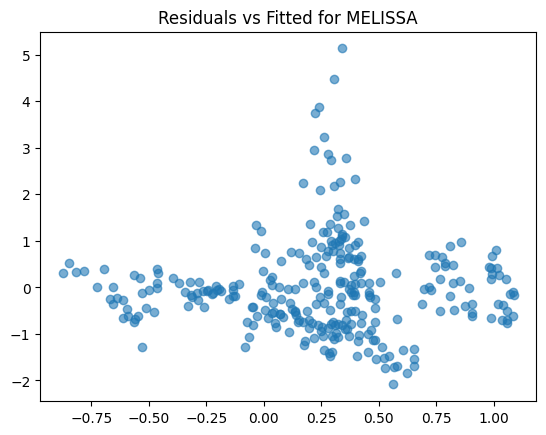

In [24]:
melissa_model1, melissa2 = storm_ols(
    df = df,
    storm_name = 'MELISSA',
    outcome = "reg_delt",
    regressors = ["distance_z", "dist2land"],
    diagnostic=True
)

melissa_model2, melissa2 = storm_ols(
    df = df,
    storm_name = 'MELISSA',
    outcome = "reg_delt",
    regressors = ["distance_z", "dist2land", "usa_wind_z"],
    diagnostic=True
)

melissa_model3, melissa3 = storm_ols(
    df = df,
    storm_name = 'MELISSA',
    outcome = "reg_delt",
    regressors = ["distance_z", "dist2land", "usa_wind_z", "storm_speed"],
    diagnostic=True
)

stargazer = Stargazer([melissa_model1, melissa_model2, melissa_model3])
stargazer.title("Regression results for Hurricane Melissa on pct. change in Regular Gas Price")
HTML(stargazer.render_html())

In [25]:
stargazer = Stargazer([model_bonnie3, model_bonnie, model_bonnie2])
stargazer.title("Regression results for Hurricane Ian on pct. change in Premium Gas Price")
HTML(stargazer.render_html())

In [40]:
regressors = ["distance_z", "dist2land", "usa_wind_z", "storm_speed"]


print("Performance metrics for the regression on Hurricane Melissa")
ols_train_test(df, "MELISSA", "reg_delt", regressors, .2)

Performance metrics for the regression on Hurricane Melissa
Rows in model_df: 288
X shape: (288, 4)
y shape: (288,)
                                0
observations           288.000000
observations in train  230.000000
observations in test    58.000000
train_rmse               0.964309
test_rmse                1.201543
train_r2                 0.156191
test_r2                  0.128533


(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x127999090>,
                                 0
 observations           288.000000
 observations in train  230.000000
 observations in test    58.000000
 train_rmse               0.964309
 test_rmse                1.201543
 train_r2                 0.156191
 test_r2                  0.128533)

## Dataframe transformation

In [26]:
df.columns

Index(['metro', 'date', 'regular', 'mid', 'premium', 'diesel', 'reg_delt',
       'met', 'lat', 'lng', 'month', 'sid', 'season', 'name', 'max cat',
       'start date', 'end date', 'storm duration', 'iso_time', 'nature',
       'dist2land', 'landfall', 'usa_lat', 'usa_lon', 'usa_record',
       'usa_status', 'usa_wind', 'usa_pres', 'usa_sshs', 'usa_poci',
       'usa_roci', 'usa_rmw', 'usa_eye', 'usa_gust', 'usa_seahgt',
       'storm_speed', 'storm_dir', 'distance', 'mid_delt', 'premium_delt',
       'diesel_delt', 'distance_z', 'usa_wind_z', 'storm_speed_z'],
      dtype='str')

In [34]:
df_mel = df[df["name"] == "MELISSA"]
df_before = df_mel[["date", "name", "regular", "mid", "premium", "diesel", "lat", "lng", "usa_lat", "usa_lon", "dist2land", "usa_wind", "storm_speed"]]
df_before.head()

,date,name,regular,mid,premium,diesel,lat,lng,usa_lat,usa_lon,dist2land,usa_wind,storm_speed
1369,2025-10-21,MELISSA,2.798,3.266,3.5645,3.4995,27.3479,-82.3223,14.0,-70.0,212.0,40.0,14.0
1370,2025-10-22,MELISSA,2.932,3.422,3.7120,3.5740,27.3479,-82.3223,14.1,-73.3,243.0,45.0,5.0
1371,2025-10-23,MELISSA,2.970,3.435,3.7380,3.5830,27.3479,-82.3223,14.3,-74.5,342.0,45.0,4.0
1372,2025-10-24,MELISSA,2.950,3.414,3.7360,3.5730,27.3479,-82.3223,15.7,-75.5,257.0,40.0,1.0
1373,2025-10-25,MELISSA,2.918,3.385,3.7090,3.5520,27.3479,-82.3223,16.1,-74.7,229.0,55.0,2.0


In [35]:
df_after = df_mel[["date", "name", "reg_delt", "mid_delt", "premium_delt", "dist2land", "distance_z", "usa_wind_z", "storm_speed"]]
df_after.head()

,date,name,reg_delt,mid_delt,premium_delt,dist2land,distance_z,usa_wind_z,storm_speed
1369,2025-10-21,MELISSA,-1.200565,-0.578387,-0.654961,212.0,-0.534993,-0.695198,14.0
1370,2025-10-22,MELISSA,4.789135,4.776485,4.138028,243.0,-0.653268,-0.511451,5.0
1371,2025-10-23,MELISSA,1.296044,0.379895,0.700431,342.0,-0.698380,-0.511451,4.0
1372,2025-10-24,MELISSA,-0.673401,-0.611354,-0.053505,257.0,-0.793226,-0.695198,1.0
1373,2025-10-25,MELISSA,-1.084746,-0.849443,-0.722698,229.0,-0.788329,-0.143959,2.0
